# Implementation 1

## Förberedelse (kör alltid)

In [2]:
import os.path
import tarfile
from urllib.request import urlretrieve

url = """http://www.cs.cornell.edu/people/pabo/movie-review-data/review_polarity.tar.gz"""
if not os.path.exists(url.split("/")[-1]):
  urlretrieve(url, url.split("/")[-1])
  print("Downloaded", url)
  with tarfile.open('review_polarity.tar.gz', 'r:gz') as tar:
    tar.extractall()
  print("Extracted archive")

In [3]:
import os

pos_path = os.path.join("txt_sentoken", "pos")
neg_path = os.path.join("txt_sentoken", "neg")

pos_files = [os.path.join(pos_path, file) for file in os.listdir(pos_path)]
neg_files = [os.path.join(neg_path, file) for file in os.listdir(neg_path)]

X_raw = []
y = []
for filepath in pos_files:
    with open(filepath, "r", encoding="utf-8") as f:
        text = f.read()
        X_raw.append(text)
        y.append(1)

for filepath in neg_files:
    with open(filepath, "r", encoding="utf-8") as f:
        text = f.read()
        X_raw.append(text)
        y.append(-1)


In [4]:
import numpy as np

y = np.array(y)
print(y.shape)

assert len(X_raw) == 2000
assert np.all([isinstance(x, str) for x in X_raw])
assert len(X_raw) == y.shape[0], "All texts must be labelled!"
assert len(np.unique(y))==2, "Only two labels (1, -1) are allowed!"
assert y.min() == -1
assert y.max() == 1

assert y[0] == 1, "Positives must be first!"
assert y[-1] == -1, "Negatives must be last!"

(2000,)


In [5]:
split_point = int(len(X_raw) * 0.8) # indices must be ints
print(split_point)
X_train = X_raw[:split_point] # index 0-1599
X_test = X_raw[split_point:] # index 1600-1999
y_train = y[:split_point]
y_test = y[split_point:]

assert len(y_train)+len(y_test) == len(y)
assert len(y_test) > 10

1600


## Binary bag of words

We implement the binary bag of words.

In [15]:
import pickle
from tqdm import tqdm

class CountVectorizer: # = feature_transform()
    def __init__(self):
        self.vocabulary = []
        self.is_fitted_ = False

    def fit(self, X):
        vocab = set()
        for review in X:
            vocab.update(review.split())
        self.vocabulary.extend(sorted(vocab)) # sorted returns a list
        self.is_fitted_ = True
        return self

    def transform(self, X):
        bag_of_words_array = []
        for review in tqdm(X):
            vector = [int(bool(x in review.split())) for x in self.vocabulary] # första gången glömde jag .split() så att det var enskilda bokstäver, men fick ändå 99+% accuracy... :O
            bag_of_words_array.append(vector)

        return np.array(bag_of_words_array)
    
    def get_feature_names_out(self):
        if self.is_fitted_:
            return np.array(self.vocabulary)

vectorizer = CountVectorizer()
vectorizer.fit(X_train)             # Creates the vocabulary of the vectorizer
assert len(vectorizer.vocabulary) != 0, "Empty vocab!"

pkl_path = os.path.join("txt_sentoken", "vectors.pkl")
if os.path.exists(pkl_path):
    with open(pkl_path, "rb") as f:
        X_train, X_test = pickle.load(f)
else:
    X_train = vectorizer.transform(X_train)
    X_test = vectorizer.transform(X_test)
    with open(pkl_path, "wb") as f:
        pickle.dump((X_train, X_test), f)

In [16]:
ordered_vocabulary = vectorizer.get_feature_names_out()
print(ordered_vocabulary)
vocabulary = set(ordered_vocabulary)

assert np.isin(X_train, [0, 1]).all(), "Non binary value in the train bag-of-words matrix!"
assert np.isin(X_test, [0, 1]).all(), "Non binary value in the test bag-of-words matrix!"

print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")

assert X_train.shape[1] == X_test.shape[1], "Train and test differ in vocab!"
assert X_train.shape[1] == len(ordered_vocabulary), "The bag-of-words contains more words than the vocab!"

['\x05' '!' '"' ... "zycie'" '|' '||']
Train shape: (1600, 45886)
Test shape: (400, 45886)


In [17]:
lut = dict()
for i, word in enumerate(ordered_vocabulary):
  lut[word] = i

for word in ['a', 'dolphin', 'the', 'coffee']:
  if word in vocabulary:
    print("'%s' is represented as feature dimension %i" %(word, lut[word]))
  else:
    print("'%s' is not in the vocabulary" % word)

'a' is represented as feature dimension 1618
'dolphin' is represented as feature dimension 12430
'the' is represented as feature dimension 40862
'coffee' is represented as feature dimension 8625


## Gradient-descent classifier

Vi slutar träna när $loss_{best} - loss_{current} > n$ för någon toleransnivå $n$, t.ex. $0.001$, under $m$ iterationer i rad, för någon tålamodsnivå $m$. Med andra ord, när lossen inte minskar tillräckligt mycket tillräckligt snabbt. Vid mitt första försök lyckades jag invertera denna lite kluriga olikhet, vilket gör att det inte konvergerar.

Det i särklass svåraste var dock att få till shapes för `X` och `_omega` och hålla tungan rätt i mun när man itererar över `X`, eftersom `_omega` ska stämma överens i dimensioner med raderna, dvs. `X.shape[1] == self._omega.shape[0]`. Just detta tog mig väldigt många försök att få rätt konsekvent genom alla methods.

Några python-metoder behövde jag lära mig för första gången. Till exempel behövde jag inse att `np.inf` existerade, innan jag kom på ett icke-godtyckligt sätt att initialisera `best_loss`, och jag lärde mig använda `np.concatenate` för att lägga till nya rader till existerande matriser.

In [18]:
class GDClassifier:
  '''This version is not called "stochastic" since the gradient comes from all the data every time...'''
  def __init__(self, regularizer_dampening=0.001, verbose=True, learning_rate=0.1, tolerance=0.001, patience=5):
    self.regularizer_dampening = regularizer_dampening
    self.verbose = verbose
    self.learning_rate = learning_rate
    self.tolerance = tolerance
    self.patience = patience

    self._omega = np.zeros(0) # initialization
    self.loss_ = []

  def fit(self, X, y):
    # add a row of pseudo-inputs
    X = self._add_pseudo_input(X)

    feature_dims = X.shape[1] # vocabulary len + 1

    self._omega = np.zeros(feature_dims) # we need parameters for every feature dimension 
    self._omega += np.random.normal(size=feature_dims) # place at a random place in the loss landscape

    assert self._omega.shape[0] == feature_dims # the shape of a feature vector needs to equal the parameter vector to do matmul

    running_out_of_patience_in = self.patience
    best_loss = np.inf # to make sure we don't start running out of patience immediately 
    iteration = 0
    while running_out_of_patience_in > 0:
      iteration += 1
      self._omega -= self.learning_rate * self._hinge_gradient(X, y)
      current_loss = self.score(X, y)
      if self.verbose:
        print(f"{iteration}: {current_loss:.0f}")
      self.loss_.append(current_loss)
      if best_loss - current_loss > self.tolerance: # if loss improves enough, we set a new best and reset patience
        best_loss = current_loss
        running_out_of_patience_in = self.patience
      else:
        running_out_of_patience_in -= 1 # if loss does not improve enough, we run out of patience
        if self.verbose:
          print(f"Patience: {running_out_of_patience_in}")
    
    return self # scikit-learn convention that "fit" returns itself

  def predict(self, X):
    '''Crisp predictions, unlike the prediction used in the hinge loss'''
    X = self._add_pseudo_input(X)
    y_hat = np.sign(X @ self._omega) # note the commuted order to avoid looping over self._omega @ X[i,:]
    assert y_hat.shape == (X.shape[0],) # one prediction per input text
    
    return y_hat

  def score(self, X, y) -> float:
    '''
    Hinge loss with l1 (FIX: not l2...) regularization.
    y are the correct labels.
    Outputs a positive float.
    '''
    regularization_term = self.regularizer_dampening * np.sum(np.abs(self._omega)) # FIXED
    raw_y_hat = X @ self._omega # uncrisp prediction. X comes first since X.shape = (1600, 46181) and _omega.shape = (46181,)
    hinge_loss_term = np.sum(np.maximum(0, 1 - y * raw_y_hat)) # a numpy function that from two input arrays a and b with the same shape returns an array c where c_ij = max(a_ij, b_ij)
    loss = regularization_term + hinge_loss_term
    
    assert isinstance(loss, float)
    assert loss >= 0

    return loss

  def _hinge_gradient(self, X, y):
    assert X.shape[0] == y.shape[0] # 1600
    assert X.shape[1] == self._omega.shape[0] # confirms that omega was initialized with the right dims

    regularization_term = self.regularizer_dampening * np.sign(self._omega) # FIXED
    gradient = regularization_term # initialize the gradient with the first term
    for i in range(X.shape[0]): # loop over n samples
      raw_y_hat_i = self._omega @ X[i, :] # (46181,) @ (46181,)
      if y[i] * raw_y_hat_i >= 1:
        continue # i.e. add 0
      else:
        gradient -= y[i] * X[i]
    return gradient
  
  def _add_pseudo_input(self, X):
    '''Add a row of pseudo-inputs'''
    n = X.shape[0]
    pseudo_input = np.ones(shape=(n, 1))
    X = np.concatenate([X, pseudo_input], axis=1) # hacky but elegant alternative: X = np.c_[X, pseudo_input]

    return X
  

In [19]:
# Set hyperparameters
regularizer_dampening = 0.0000079  # λ
learning_rate = 0.0000101          # γ with order of magnitude e-3 and larger does not seem to converge (before my own patience runs out)

# Create the untrained classifier
model = GDClassifier(regularizer_dampening=regularizer_dampening,
                      learning_rate=learning_rate)

# Train the classifier
model.fit(X_train, y_train)

# Get the parameter vector
omega = model._omega

# Plot the loss curve
loss = model.loss_

import matplotlib.pyplot as plt

plt.plot(loss)
plt.show()


1: 10237
2: 10223
3: 10209
4: 10197
5: 10185
6: 10173
7: 10162
8: 10151
9: 10140
10: 10130
11: 10120
12: 10111
13: 10102
14: 10094
15: 10085
16: 10076
17: 10068
18: 10059
19: 10051
20: 10043
21: 10035
22: 10027
23: 10020
24: 10013
25: 10005
26: 9998
27: 9992
28: 9985
29: 9979
30: 9972
31: 9966
32: 9960
33: 9954
34: 9948
35: 9942
36: 9936
37: 9930
38: 9924
39: 9919
40: 9913
41: 9908
42: 9902
43: 9897
44: 9891
45: 9886
46: 9880
47: 9875
48: 9870
49: 9864
50: 9859
51: 9854
52: 9849
53: 9844
54: 9839
55: 9834
56: 9829
57: 9824
58: 9819
59: 9814
60: 9809
61: 9803
62: 9798
63: 9793
64: 9788
65: 9783
66: 9778
67: 9773
68: 9768
69: 9764
70: 9759
71: 9754
72: 9749
73: 9744
74: 9739
75: 9734
76: 9729
77: 9724
78: 9719
79: 9714
80: 9709
81: 9704
82: 9699
83: 9694
84: 9689
85: 9684
86: 9679
87: 9675
88: 9670
89: 9665
90: 9660
91: 9656
92: 9651
93: 9646
94: 9641
95: 9636
96: 9632
97: 9627
98: 9622
99: 9617
100: 9613
101: 9608
102: 9603
103: 9598
104: 9594
105: 9589
106: 9584
107: 9579
108: 9575
109

KeyboardInterrupt: 

Vikterna är mycket mer jämnt fördelade än i Fredriks sklearn-impementation. Känns som att det betyder att en del skräp har fått onödigt höga vikter. 

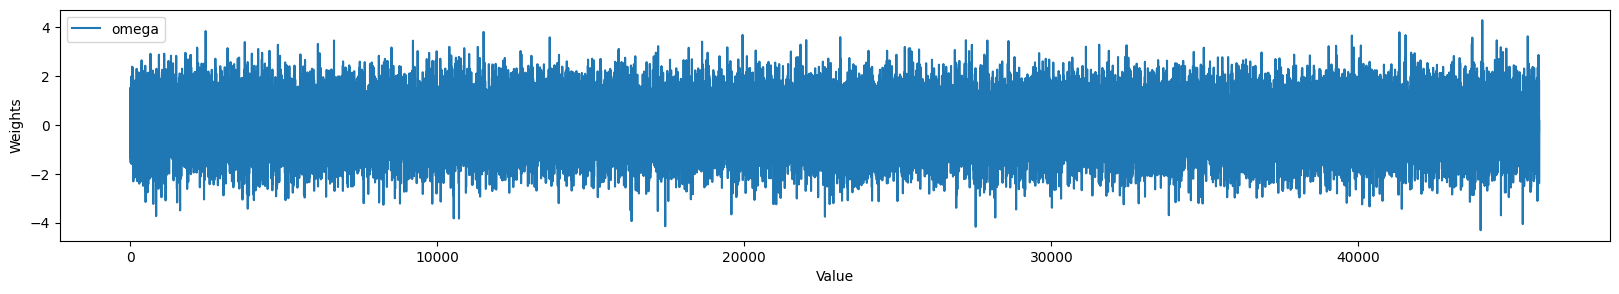

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 3))

plt.plot(omega[1:], label="omega")

plt.xlabel("Value")
plt.ylabel("Weights")
plt.legend()

plt.show()

Lot's of words with 1 occurance are getting high weights, which is of course useless for generalization. I suspect some of these are specific to certain movie titles that appear in only a single review, and hence get overtrained.

In [36]:
assert (len(omega)-1) == len(vocabulary)

# Sort by absolute value
idx = np.argsort(np.abs(omega[1:]))

print("                Word   Weight  Occurences")
for i in idx[-30:]:   # Pick those with highest 'voting' values
  print("%20s   %.3f\t%i " % (ordered_vocabulary[i], omega[i+1], np.sum([ordered_vocabulary[i] in d for d in X_raw])))

                Word   Weight  Occurences
             synched   3.356	4 
             lithium   -3.357	2 
            threeway   -3.393	1 
              dudley   -3.393	5 
           wire-work   -3.407	1 
         unbreakable   3.421	7 
              hasn't   3.422	90 
           massaging   -3.424	2 
            long--so   3.448	1 
          unarguable   3.460	1 
          excellence   3.474	4 
                vega   -3.477	65 
        blond-haired   -3.480	2 
          9-year-old   -3.537	3 
             adopted   3.540	15 
           dirt-poor   3.561	1 
           stridency   -3.596	1 
               ditch   -3.598	20 
                marc   3.598	91 
            coladas'   -3.636	1 
            slawomir   -3.644	1 
          scrap-pile   -3.725	1 
             floored   3.731	2 
        pre-occupied   3.795	1 
              kidnap   -3.819	90 
              lola's   -3.895	2 
          spaceballs   -3.911	3 
               fox's   -4.062	6 
             gabriel   4.217	37 
      

### Hyperparameteroptimisering

Såg vid första körningarna att alla bra parametrar var <= e-4, och för lr t.o.m. <= e-5, så har anpassat gränserna för `logspace`. Vid dessa låga lrs är konvergensen dock *mycket* långsam, så tar timtals att bara få 10 stycken samples.

In [ ]:
from collections import defaultdict
from concurrent.futures import ThreadPoolExecutor

def get_best_hyperparams(n_samples=1):
  acc_grid = defaultdict(dict) # I like defaultdicts

  best_hyperparameters = (0.1, 0.001, 0.0)

  rand_gen = np.random.default_rng() # stod i manualen att detta var den senaste syntaxen
  for learning_rate, regularizer_dampening in tqdm(zip(rand_gen.choice(np.logspace(-6, -5, num=1000, base=10.0), n_samples),
                                                rand_gen.choice(np.logspace(-5, -4, num=1000, base=10.0), n_samples)), total=n_samples):

    model = GDClassifier(regularizer_dampening=regularizer_dampening, 
                          verbose=False,
                          learning_rate=learning_rate)

    print("Fitting lr %.7f and λ %.7f..." % (learning_rate, regularizer_dampening))
    model.fit(X_train, y_train)

    training_accuracy = np.sum(model.predict(X_train)==y_train)/len(y_train)

    acc_grid[learning_rate][regularizer_dampening] = training_accuracy # outer and inner dicts

    with open("hyperparams.tsv", "a") as f:
      f.write(f"{learning_rate}\t{regularizer_dampening}\t{training_accuracy}\n")
    
    if best_hyperparameters is None or best_hyperparameters[2] < training_accuracy:
      best_hyperparameters = (learning_rate, regularizer_dampening, training_accuracy)
      print("%.7f\t\t%.7f\t\t%.2f%%" % (learning_rate, regularizer_dampening, 100*training_accuracy))
    
  return best_hyperparameters

best_hyperparameters = get_best_hyperparams(20)

  0%|                           | 0/20 [00:00<?, ?it/s]

Fitting lr 0.0000012 and λ 0.0000442...


  0%|                           | 0/20 [00:02<?, ?it/s]


KeyboardInterrupt: 

För att undvika att förlora alla checkade värden vid eventuell kernel-krash, så appendar jag till och laddar från en tsv.

In [43]:
acc_grid = defaultdict(dict)
with open("hyperparams.tsv", "r") as f:
  grid_results = {}
  for line in f:
    learning_rate, regularizer_dampening, training_accuracy = line.strip().split("\t")
    learning_rate = float(learning_rate)
    regularizer_dampening = float(regularizer_dampening)
    training_accuracy = float(training_accuracy)
    grid_results[(learning_rate, regularizer_dampening)] = training_accuracy
    acc_grid[learning_rate][regularizer_dampening] = training_accuracy # outer and inner dicts


best_learning_rate_gd, best_regularizer_dampening_gd = max(grid_results, key=lambda x: grid_results[x])

print("Best parameters: %.6f, %.6f" % (best_learning_rate_gd, best_regularizer_dampening_gd))

Best parameters: 0.000008, 0.000010


In [44]:
from tabulate import tabulate # för att slippa printa all tabellens ascii-art manuellt

lambdas = set()
for inner_dict in acc_grid.values():
    lambdas.update(inner_dict.keys()) # update is like append but for sets

lrs = sorted(acc_grid.keys()) # the keys are lrs only because its a nested dictionary
lambdas = sorted(lambdas)

headers = ["lr \\ lambda"] + [f"{lam:.1e}" for lam in lambdas] # elementet (0,0) i griden har ingen kombination 

rows = []

for lr in lrs:
    row = [f"{lr:.1e}"] # första kolumnen har lr-headers
    for lam in lambdas:
        inner = acc_grid.get(lr)
        acc = None if inner is None else inner.get(lam)
        row.append("" if acc is None else f"{acc*100:.2f}%")
    rows.append(row)

print(tabulate(rows, headers=headers, tablefmt="grid"))

+---------------+-----------+
|   lr \ lambda | 1.0e-05   |
+===============+===========+
|       7.9e-06 | 97.94%    |
+---------------+-----------+


In [46]:
# Set up the classifier
model = GDClassifier(regularizer_dampening=best_regularizer_dampening_gd, 
                    verbose=True,
                    learning_rate=best_learning_rate_gd)

# Train on all the non-test data
model.fit(X_train, y_train)

# Run prediction on the test set
test_accuracy = np.sum(model.predict(X_test)==y_test)/len(y_test)

print("Test set accuracy %.1f%%" % (100*test_accuracy))

1: 12611
2: 12535
3: 12463
4: 12396
5: 12332
6: 12270
7: 12211
8: 12154
9: 12100
10: 12047
11: 11996
12: 11946
13: 11899
14: 11854
15: 11810
16: 11768
17: 11728
18: 11689
19: 11652
20: 11617
21: 11584
22: 11552
23: 11522
24: 11492
25: 11464
26: 11438
27: 11413
28: 11390
29: 11367
30: 11344
31: 11322
32: 11300
33: 11279
34: 11259
35: 11239
36: 11220
37: 11201
38: 11184
39: 11167
40: 11150
41: 11134
42: 11118
43: 11103
44: 11088
45: 11073
46: 11059
47: 11045
48: 11031
49: 11017
50: 11004
51: 10992
52: 10980
53: 10969
54: 10958
55: 10947
56: 10936
57: 10926
58: 10917
59: 10907
60: 10897
61: 10888
62: 10879
63: 10870
64: 10861
65: 10853
66: 10845
67: 10837
68: 10829
69: 10822
70: 10814
71: 10806
72: 10799
73: 10791
74: 10784
75: 10777
76: 10770
77: 10763
78: 10757
79: 10750
80: 10744
81: 10737
82: 10731
83: 10725
84: 10719
85: 10713
86: 10707
87: 10702
88: 10696
89: 10690
90: 10685
91: 10679
92: 10674
93: 10668
94: 10663
95: 10658
96: 10652
97: 10647
98: 10642
99: 10637
100: 10631
101: 106

KeyboardInterrupt: 

# Implementation 2

Här implementerar succesivt en `SGDClassifier` med

- stochastisk mini-batch gradient descent
- ExponentialLR learning-rate scheduler, med en decay rate som hyperparameter (https://machinelearningmastery.com/a-gentle-introduction-to-learning-rate-schedulers/). Kräver bara tre små ändringar i koden.

Vi börjar dock med en *term frequency–inverse document frequency*-vektoriserare:

### TF-IDF

Här skapar vi en vektoriserare med TF-IDF-vikter.

In [10]:
from collections import defaultdict, Counter
from tqdm import tqdm

class CountVectorizerTFIDF:
    '''
    tf räknar ord
    tf = antal förekomster av term t i dokument d, över totalt antal ord (med dubletter) i d

    idf räknar dokument
    idf = log av kvoten mellan totalt antal dokument N och antal dokument n_t innehållandes t
    '''
    def __init__(self):
        self.vocabulary = []
        self.idf_ = {}
        self.is_fitted_ = False

    def fit(self, X):
        '''
        Hitta vocab med en iteration genom alla docs och sen idf med en iteration genom vokabulären.
        '''
        vocab = set()
        doc_freq = defaultdict(int)

        for doc in X: # kombinera vocab och idf i samma loop för att slippa iterera genom alla dokument flera gånger
            terms = set(doc.split())
            vocab.update(terms)
            for term in terms:
                doc_freq[term] += 1 # vi räknar n_t för alla t

        self.vocabulary = sorted(vocab) # sorted returns a list

        N = len(X)
        for term in self.vocabulary:
            n_t = doc_freq[term] # färdigräknat
            idf = np.log(N / n_t)
            self.idf_[term] = idf

        self.is_fitted_ = True
        return self

    def transform(self, X):
        '''
        updated
        '''
        bag_of_words_array = []
        vocabulary_set = set(self.vocabulary)
        
        for doc in tqdm(X):
            terms = doc.split()
            counter = Counter(terms)
            tf_idf_weight = defaultdict(int) # set default to zero
            for t in counter:
                if t in vocabulary_set:
                    tf = counter[t] / counter.total() # .total() ger just totalt antal ord med dubletter
                    idf = self.idf_[t]
                    tf_idf = tf * idf
                    tf_idf_weight[t] = tf_idf
            vector = [tf_idf_weight.get(term, 0.0) for term in self.vocabulary]
            #print(vector)
            #print(len([float(digit) for digit in vector if digit > 0]), f"non-zero values out of {len(vector)}")
            bag_of_words_array.append(vector)

        return np.array(bag_of_words_array)
    
    def get_feature_names_out(self):
        if self.is_fitted_:
            return np.array(self.vocabulary)

In [7]:
assert len(X_train) == 1600

In [12]:
vectorizer = CountVectorizerTFIDF()
vectorizer.fit(X_train)             # Creates the vocabulary of the vectorizer
assert len(vectorizer.vocabulary) != 0, "Empty vocab!"

In [13]:
# Pickle för snabbare tester

pkl_path = os.path.join("txt_sentoken", "vectors_tfidf.pkl")
if os.path.exists(pkl_path):
    with open(pkl_path, "rb") as f:
        X_train_tfidf, X_test_tfidf = pickle.load(f)
else:
    X_train_tfidf = vectorizer.transform(X_train)
    X_test_tfidf = vectorizer.transform(X_test)

    with open(pkl_path, "wb") as f:
        pickle.dump((X_train_tfidf, X_test_tfidf), f)

  0%|              | 0/1600 [00:00<?, ?it/s]

100%|████| 400/400 [00:01<00:00, 389.69it/s]


### Mini-batch SGD classifier

Batchingen innebär bara en uppdatering av `fit()`.

In [19]:
class SGDClassifier:
  '''This version is truly "stochastic" since the gradient is calculated from random batches.'''
  def __init__(self, regularizer_dampening=0.001, verbose=True, learning_rate=0.1, tolerance=0.001, patience=5, batches=10):
    self.regularizer_dampening = regularizer_dampening
    self.verbose = verbose
    self.learning_rate = learning_rate
    self.tolerance = tolerance
    self.patience = patience
    self.batches = batches

    self.current_batch = 0

    self._omega = np.zeros(0)
    self.loss_ = []

  def fit(self, X, y):
    X = self._add_pseudo_iput(X)

    feature_dims = X.shape[1]

    self._omega = np.zeros(feature_dims)
    self._omega += np.random.normal(size=feature_dims)

    assert self._omega.shape[0] == feature_dims

    running_out_of_patience_in = self.patience
    best_loss = np.inf
    iteration = 0
    while running_out_of_patience_in > 0:
      iteration += 1
      ### Beginning of SGD upgrade ###
      n = X.shape[0]
      batch_size = n // self.batches
      self.current_batch = np.random.randint(0, self.batches)
      if self.current_batch == self.batches - 1: # the last batch gets the eventual remainder
        batch_size += n % self.batches

      indices = np.random.choice(n, size=batch_size, replace=False) # NYTT: shuffla batches

      X_batch = X[indices]
      y_batch = y[indices]

      self._omega -= self.learning_rate * self._hinge_gradient(X_batch, y_batch)
      current_loss = self.score(X, y)
      ### End of SGD upgrade ###
      if self.verbose:
        print(f"{iteration} (batch {self.current_batch + 1}/{self.batches}): {current_loss:.0f}")
      self.loss_.append(current_loss)
      if best_loss - current_loss > self.tolerance:
        best_loss = current_loss
        running_out_of_patience_in = self.patience
      else:
        running_out_of_patience_in -= 1
        if self.verbose:
          print(f"Patience: {running_out_of_patience_in}")
    
    return self

  def predict(self, X):
    '''Crisp predictions, unlike the prediction used in the hinge loss'''
    X = self._add_pseudo_iput(X)
    y_hat = np.sign(X @ self._omega)
    assert y_hat.shape == (X.shape[0],)
    
    return y_hat

  def score(self, X, y) -> float:
    '''
    Hinge loss with l1 regularization.
    y are the correct labels.
    Outputs a positive float.
    '''
    regularization_term = self.regularizer_dampening * np.sum(np.abs(self._omega)) # FIXED
    raw_y_hat = X @ self._omega
    hinge_loss_term = np.sum(np.maximum(0, 1 - y * raw_y_hat))
    loss = regularization_term + hinge_loss_term
    
    assert isinstance(loss, float)
    assert loss >= 0

    return loss

  def _hinge_gradient(self, X, y):
    assert X.shape[1] == self._omega.shape[0]

    regularization_term = self.regularizer_dampening * np.sign(self._omega) # FIXED
    gradient = regularization_term
    for i in range(X.shape[0]):
      raw_y_hat_i = self._omega @ X[i, :]
      if y[i] * raw_y_hat_i >= 1:
        continue
      else:
        gradient -= y[i] * X[i]
    return gradient / X.shape[0] # NYTT: normalisera gradienterna
  
  def _add_pseudo_iput(self, X):
    '''Add a row of pseudo-inputs'''
    n = X.shape[0]
    pseudo_input = np.ones(shape=(n, 1))
    X = np.concatenate([X, pseudo_input], axis=1) # hacky but elegant alternative: X = np.c_[X, pseudo_input]

    return X
  

In [20]:
print("X_train_tfidf:", X_train_tfidf.shape)
print("y_train:", y_train.shape)
assert X_train_tfidf.shape[0] == y_train.shape[0]

X_train_tfidf: (1600, 45886)
y_train: (1600,)


1 (batch 6/10): 1497
2 (batch 4/10): 1497
3 (batch 6/10): 1497
4 (batch 2/10): 1497
5 (batch 2/10): 1497
6 (batch 1/10): 1497
7 (batch 2/10): 1497
8 (batch 6/10): 1497
9 (batch 7/10): 1497
10 (batch 9/10): 1496
11 (batch 1/10): 1496
12 (batch 9/10): 1496
13 (batch 9/10): 1496
14 (batch 6/10): 1496
15 (batch 6/10): 1496
16 (batch 4/10): 1496
17 (batch 8/10): 1496
18 (batch 2/10): 1496
19 (batch 9/10): 1496
20 (batch 8/10): 1496
21 (batch 5/10): 1495
22 (batch 3/10): 1495
23 (batch 7/10): 1495
24 (batch 8/10): 1495
25 (batch 1/10): 1495
26 (batch 5/10): 1495
27 (batch 8/10): 1495
28 (batch 7/10): 1495
29 (batch 4/10): 1495
30 (batch 8/10): 1495
31 (batch 9/10): 1494
32 (batch 4/10): 1494
33 (batch 3/10): 1494
34 (batch 4/10): 1494
35 (batch 2/10): 1494
36 (batch 2/10): 1494
37 (batch 1/10): 1494
38 (batch 6/10): 1494
39 (batch 7/10): 1494
40 (batch 9/10): 1494
41 (batch 2/10): 1493
42 (batch 1/10): 1493
43 (batch 4/10): 1493
44 (batch 6/10): 1493
45 (batch 2/10): 1493
46 (batch 5/10): 14

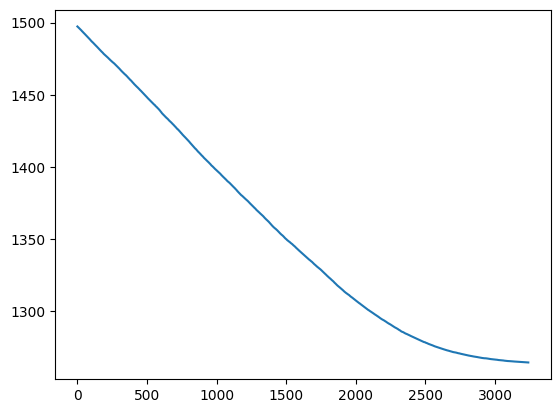

In [23]:
# Set hyperparameters
regularizer_dampening = 0.0001   # λ
learning_rate = 0.001          # γ with order of magnitude e-3 and larger does not seem to converge (before my own patience runs out)

# Create the untrained classifier
model_sgd = SGDClassifier(regularizer_dampening=regularizer_dampening,
                      learning_rate=learning_rate)

# Train the classifier
model_sgd.fit(X_train_tfidf, y_train)

# Get the parameter vector
omega_sgd = model_sgd._omega

# Plot the loss curve
loss_sgd = model_sgd.loss_

import matplotlib.pyplot as plt

plt.plot(loss_sgd)
plt.show()


### SGD med learning-rate scheduler

In [53]:
class SGDClassifierExponentialLR:
  '''
  Fancy gradient descent with mini batches and exponential learning-rate scheduler.
  '''
  def __init__(self, regularizer_dampening=0.001, verbose=True, decay_rate=0.99, tolerance=1e-4, patience=5, batches=10, initial_lr=0.1):
    self.regularizer_dampening = regularizer_dampening
    self.verbose = verbose
    self.initial_lr = initial_lr # NYTT
    self.decay_rate = decay_rate
    self.tolerance = tolerance # with batches + exp lr we need smalled tolerance otherwise we will rarely "beat" the best loss
    self.patience = patience
    self.batches = batches

    self.current_batch = 0

    self._omega = np.zeros(0)
    self.loss_ = []
    self.lr_ = []

  def fit(self, X, y):
    X = self._add_pseudo_iput(X)

    feature_dims = X.shape[1]

    self._omega = np.zeros(feature_dims)
    self._omega += np.random.normal(size=feature_dims)

    assert self._omega.shape[0] == feature_dims

    running_out_of_patience_in = self.patience
    best_loss = np.inf
    iteration = 0
    while running_out_of_patience_in > 0:
      iteration += 1
      n = X.shape[0]
      batch_size = n // self.batches
      self.current_batch = np.random.randint(0, self.batches)
      if self.current_batch == self.batches - 1:
        batch_size += n % self.batches

      indices = np.random.choice(n, size=batch_size, replace=False) # NYTT: shuffla batches

      X_batch = X[indices]
      y_batch = y[indices]

      assert X_batch.shape[0] != 0 # försäkra oss om att batchen inte är tom/buggad

      self._omega -= self._ExponentialLR(iteration) * self._hinge_gradient(X_batch, y_batch) # <-- den nya descenten
      current_loss = self.score(X, y)
      if self.verbose:
        print(f"Epoch {iteration}, batch {self.current_batch + 1}/{self.batches}, γ = {self.lr_[-1]}: {current_loss:.0f}")
      self.loss_.append(current_loss)
      if best_loss - current_loss > self.tolerance:
        best_loss = current_loss
        running_out_of_patience_in = self.patience
      else:
        running_out_of_patience_in -= 1
        if self.verbose:
          print(f"Patience: {running_out_of_patience_in}")
    
    return self

  def predict(self, X):
    '''Crisp predictions, unlike the prediction used in the hinge loss'''
    X = self._add_pseudo_iput(X)
    y_hat = np.sign(X @ self._omega)
    assert y_hat.shape == (X.shape[0],)
    
    return y_hat

  def score(self, X, y) -> float:
    '''
    Hinge loss with l1 regularization.
    y are the correct labels.
    Outputs a positive float.
    '''
    regularization_term = self.regularizer_dampening * np.sum(np.abs(self._omega)) # FIXED
    raw_y_hat = X @ self._omega
    hinge_loss_term = np.sum(np.maximum(0, 1 - y * raw_y_hat))
    loss = regularization_term + hinge_loss_term
    
    assert isinstance(loss, float)
    assert loss >= 0

    return loss

  def _hinge_gradient(self, X, y):
    assert X.shape[0] == y.shape[0]
    assert X.shape[1] == self._omega.shape[0]

    # ***Loop-version***
    #
    # regularization_term = self.regularizer_dampening * np.sign(self._omega)
    # grad = regularization_term
    # for i in range(X.shape[0]):
    #   raw_y_hat_i = self._omega @ X[i, :]
    #   if y[i] * raw_y_hat_i >= 1:
    #     continue
    #   else:
    #     grad -= y[i] * X[i]
    # return grad / X.shape[0]

    # 1. calculate all margins
    margins = y * (X @ self._omega) # distances to the decision-boundary hyperplane: negative if pred is wrong sign i.e. on the wrong side of the hyperplane, positive otherwise, the larger the better
    mask = margins < 1 # pick out the "incorrect or too unsure" preds
    
    grad = self.regularizer_dampening * np.sign(self._omega)
    
    # 2. pick out the preds with too small margins and their resp. inputs
    violating_X = X[mask]
    violating_y = y[mask] # (X.shape(0),)
    
    # 3. calculate the contribution from all the violating preds (cf. the earlier grad -= y[i] * X[i])
    
    # i. vi gör först y till en matris ("broadcasting"), i två steg (andra steget är egentligen automatiskt i numpy men jag vill groka det när jag läser om koden i framtiden)
    violating_y_column = violating_y.reshape(-1, 1) # (X.shape(0),) -> (X.shape(0), 1)
    violating_y_broadcasted = np.broadcast_to(violating_y_column, violating_X.shape)  # (X.shape(0), 1) -> (X.shape(0), d)
    
    # ii. yi * Xij 
    contrib = violating_y_broadcasted * violating_X 
    grad -= contrib.sum(axis=0)
    
    # 4. normalize by batch size (avoid batch size determining learning rate)
    return grad / X.shape[0]

  def _add_pseudo_iput(self, X):
    '''Add a row of pseudo-inputs'''
    n = X.shape[0]
    pseudo_input = np.ones(shape=(n, 1))
    X = np.concatenate([X, pseudo_input], axis=1)

    return X
  
  def _ExponentialLR(self, t):
    epoch = t // self.batches
    lr = self.initial_lr * (self.decay_rate ** epoch)
    self.lr_.append(lr) # dvs när t = 0, så är lr = initial_lr
    return lr
  

Epoch 1, batch 8/10, γ = 0.1: 2734
Epoch 2, batch 7/10, γ = 0.1: 2672
Epoch 3, batch 5/10, γ = 0.1: 2618
Epoch 4, batch 7/10, γ = 0.1: 2559
Epoch 5, batch 5/10, γ = 0.1: 2501
Epoch 6, batch 8/10, γ = 0.1: 2433
Epoch 7, batch 2/10, γ = 0.1: 2374
Epoch 8, batch 7/10, γ = 0.1: 2312
Epoch 9, batch 10/10, γ = 0.1: 2257
Epoch 10, batch 6/10, γ = 0.0995: 2203
Epoch 11, batch 8/10, γ = 0.0995: 2153
Epoch 12, batch 1/10, γ = 0.0995: 2109
Epoch 13, batch 3/10, γ = 0.0995: 2069
Epoch 14, batch 2/10, γ = 0.0995: 2032
Epoch 15, batch 10/10, γ = 0.0995: 2002
Epoch 16, batch 9/10, γ = 0.0995: 1981
Epoch 17, batch 3/10, γ = 0.0995: 1960
Epoch 18, batch 8/10, γ = 0.0995: 1950
Epoch 19, batch 4/10, γ = 0.0995: 1943
Epoch 20, batch 3/10, γ = 0.09900250000000001: 1936
Epoch 21, batch 5/10, γ = 0.09900250000000001: 1923
Epoch 22, batch 3/10, γ = 0.09900250000000001: 1910
Epoch 23, batch 8/10, γ = 0.09900250000000001: 1895
Epoch 24, batch 3/10, γ = 0.09900250000000001: 1883
Epoch 25, batch 8/10, γ = 0.09900

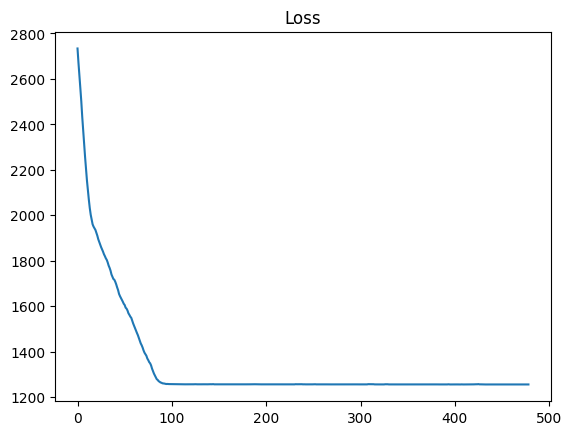

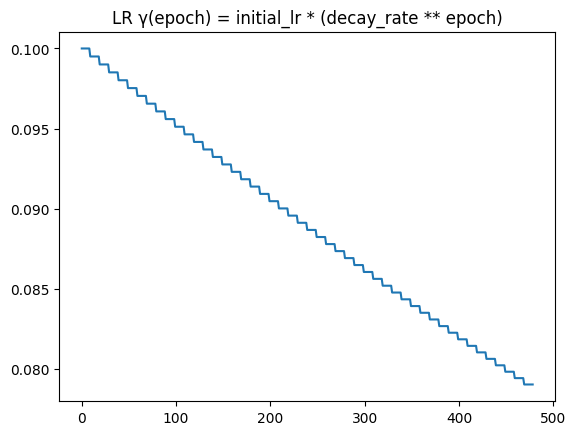

In [54]:
# Set hyperparameters
regularizer_dampening = 0.0001   # λ

# Create the untrained classifier
model_sgde = SGDClassifierExponentialLR(regularizer_dampening=regularizer_dampening, decay_rate=0.995, patience=20, initial_lr=0.1)

# Train the classifier
model_sgde.fit(X_train_tfidf, y_train)

omega_sgde = model_sgde._omega
loss_sgde = model_sgde.loss_
lr_sgde = model_sgde.lr_

import matplotlib.pyplot as plt

plt.title("Loss")
plt.plot(loss_sgde)
plt.show()

plt.title("LR γ(epoch) = initial_lr * (decay_rate ** epoch)")
plt.plot(lr_sgde)
plt.show()


# K-fold cross validation

Vi implementerar k-faldig korsvalidering, men först måste vi såklart ta fram bra hyperparametrar åt de två nya modellerna för att få en rättvis jämförelse, eftersom `GDClassifier` har optimerats.

In [ ]:
def get_best_hyperparams_sgd(type="GDClassifier", =10):
  rand_gen = np.random.default_rng()

  best_hyperparams_1 = 0
  best_hyperparams_2 = 0
  best_accuracy = 0

  if type == "SGDClassifier":
    for learning_rate, regularizer_dampening in tqdm(zip(rand_gen.choice(np.logspace(-6, -5, num=1000, base=10.0), n_samples),
                                                  rand_gen.choice(np.logspace(-6, -5, num=1000, base=10.0), n_samples)), total=n_samples):

      model = SGDClassifier(regularizer_dampening=regularizer_dampening, learning_rate=learning_rate, batches=10)
      model.fit(X_train, y_train)
      training_accuracy = np.sum(model.predict(X_train)==y_train)/len(y_train)

      if training_accuracy > best_accuracy:
        best_accuracy = training_accuracy
        best_hyperparams_1 = learning_rate
        best_hyperparams_2 = regularizer_dampening

  elif type == "SGDClassifierExponentialLR":
    for decay_rate, regularizer_dampening in tqdm(zip(rand_gen.choice(np.linspace(0.5, 1, num=1000), n_samples), # tänker att decay rate kan sökas inom ett mindre intervall än lr och lambda
                                                  rand_gen.choice(np.logspace(-6, -5, num=1000, base=10.0), n_samples)), total=n_samples):

      model = SGDClassifierExponentialLR(regularizer_dampening=regularizer_dampening, batches=10, decay_rate=decay_rate)
      model.fit(X_train, y_train)
      training_accuracy = np.sum(model.predict(X_train)==y_train)/len(y_train)

      if training_accuracy > best_accuracy:
        best_accuracy = training_accuracy
        best_hyperparams_1 = decay_rate
        best_hyperparams_2 = regularizer_dampening
        
  with open(f"hyperparams_{type}.tsv", "a") as f:
    f.write(f"{best_hyperparams_1}\t{best_hyperparams_2}\n")

  return best_hyperparams_1, best_hyperparams_2

In [53]:
best_learning_rate_sgd, best_regularizer_dampening_sgd = get_best_hyperparams_sgd("SGDClassifier", n_samples=10)

best_decay_rate_sgde, best_regularizer_dampening_sgde = get_best_hyperparams_sgd("SGDClassifierExponentialLR", n_samples=10)



1 (batch 3/10): 10610
2 (batch 7/10): 10611
Patience: 4
3 (batch 2/10): 10610
4 (batch 6/10): 10608
5 (batch 3/10): 10606
6 (batch 6/10): 10604
7 (batch 8/10): 10606
Patience: 4
8 (batch 1/10): 10604
Patience: 3
9 (batch 9/10): 10606
Patience: 2
10 (batch 10/10): 10608
Patience: 1
11 (batch 8/10): 10610
Patience: 0
1 (batch 4/10): 11127
2 (batch 3/10): 11125
3 (batch 4/10): 11123
4 (batch 1/10): 11122
5 (batch 3/10): 11120
6 (batch 1/10): 11119
7 (batch 3/10): 11118
8 (batch 2/10): 11117
9 (batch 1/10): 11115
10 (batch 9/10): 11117
Patience: 4
11 (batch 9/10): 11119
Patience: 3
12 (batch 8/10): 11121
Patience: 2
13 (batch 6/10): 11119
Patience: 1
14 (batch 3/10): 11118
Patience: 0
1 (batch 4/10): 11847
2 (batch 2/10): 11839
3 (batch 8/10): 11845
Patience: 4
4 (batch 6/10): 11838
5 (batch 6/10): 11830
6 (batch 3/10): 11822
7 (batch 4/10): 11814
8 (batch 9/10): 11821
Patience: 4
9 (batch 2/10): 11813
10 (batch 4/10): 11805
11 (batch 9/10): 11812
Patience: 4
12 (batch 7/10): 11815
Patienc

In [ ]:
import time

def model_test(X_train, y_train, X_test, y_test, regularizer_dampening, learning_rate=None, batches=None, decay_rate=None):
    if learning_rate:
        model = GDClassifier(regularizer_dampening=regularizer_dampening, learning_rate=learning_rate)

    elif batches and not decay_rate:
        model = SGDClassifier(regularizer_dampening=regularizer_dampening, learning_rate=learning_rate, batches=batches)

    else: 
        model = SGDClassifierExponentialLR(regularizer_dampening=regularizer_dampening, batches=batches, decay_rate=decay_rate)

    # Train
    model.fit(X_train, y_train)

    # Test
    t_0 = time.time()
    test_accuracy = np.sum(model.predict(X_test)==y_test)/len(y_test)
    t_1 = time.time()

    duration = t_1 - t_0

    loss = model.loss_
    lr = model.lr_

    import matplotlib.pyplot as plt

    plt.title("Loss")
    plt.plot(loss)
    plt.show()

    plt.title("LR γ(t) = exp(-t * decay rate)")
    plt.plot(lr)
    plt.show()

    return test_accuracy, duration

results = {"GD": 0, "SGD": 0, "SGDExponential": 0}
K = 10
n = len(X_raw)
fold_size = n // K # floor it for now

for k in range(K):
    start = k * fold_size
    end = (k + 1) * fold_size if k < K - 1 else n # last fold (k = K-1) gets eventual remainder

    X_test_TEMP = X_raw[start:end]
    y_test_TEMP = y[start:end]

    X_train_TEMP = np.concatenate((X_raw[:start], X_raw[end:]), axis=0) # najs att få använda concatenate till mer än pseudo-input
    y_train_TEMP = np.concatenate((y[:start], y[end:]), axis=0)

    vectorizer = CountVectorizerTFIDF()
    vectorizer.fit(X_train_TEMP)
    X_train = vectorizer.transform(X_train_TEMP)
    X_test = vectorizer.transform(X_test_TEMP)

    results["GD"] = model_test(X_train, y_train_TEMP, X_test, y_test_TEMP, regularizer_dampening=best_regularizer_dampening_gd, learning_rate=best_learning_rate_gd)
    results["SGD"] = model_test(X_train, y_train_TEMP, X_test, y_test_TEMP, regularizer_dampening=best_regularizer_dampening_sgd, learning_rate=best_learning_rate_sgd, batches=10)
    results["SGDExponential"] = model_test(X_train, y_train_TEMP, X_test, y_test_TEMP, regularizer_dampening=best_regularizer_dampening_sgde, batches=10, decay_rate=best_decay_rate_sgde)



NameError: name 'CountVectorizerTFIDF' is not defined